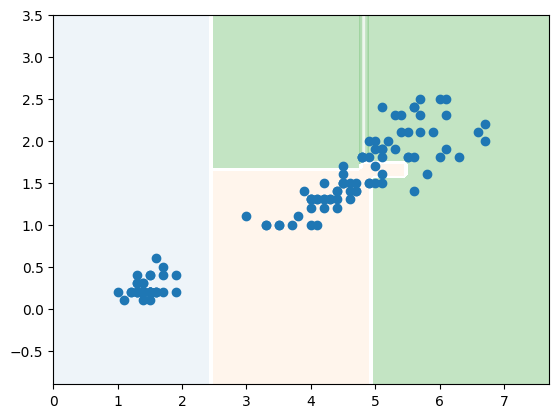

Accuracy :  1.0
Actual values :  1 Predicted :  1
Actual values :  0 Predicted :  0
Actual values :  2 Predicted :  2
Actual values :  1 Predicted :  1
Actual values :  1 Predicted :  1


In [2]:
# Q1
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

data = load_iris()
x = data.data[:,[2,3]]
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

model = DecisionTreeClassifier()
model.fit(x_train,y_train)
DecisionBoundaryDisplay.from_estimator(model,x_train,alpha = 0.3)

plt.scatter(x_train[:,0],x_train[:,1])
plt.show()

print("Accuracy : ",model.score(x_test,y_test))

pred = model.predict(x_test)
for i in range(5):
    print(f"Actual values : ",y_test[i], f"Predicted : ",pred[i])


Enter texts :  nasa created rover


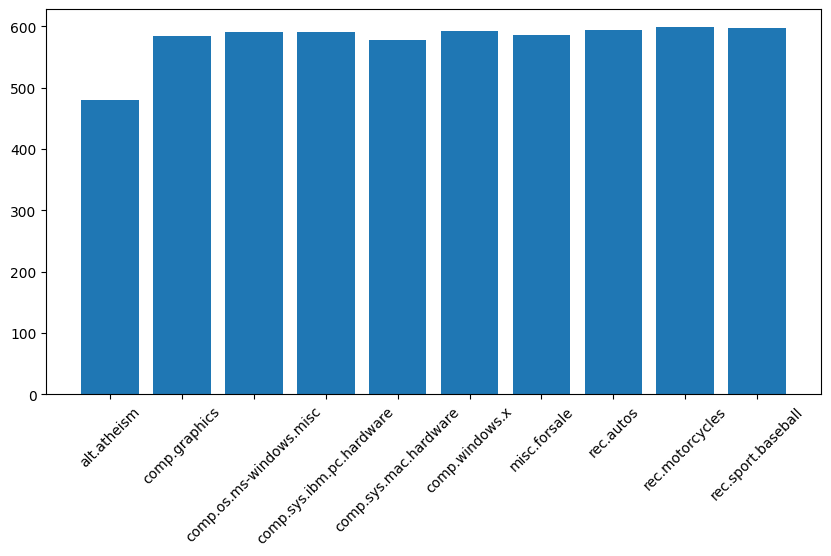

In [17]:
# Q2

import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
data = fetch_20newsgroups(subset = 'train')
texts = data.data
vec = CountVectorizer(stop_words = 'english')
x = vec.fit_transform(texts)

y = data.target
labels = data.target_names

model = MultinomialNB()
model.fit(x,y)

texts = input("Enter texts : ")
pred = model.predict(vec.transform([texts]))

counts = np.bincount(y)

plt.figure(figsize=(10,5))
plt.bar(range(10),counts[:10])
plt.xticks(range(10),labels[:10],rotation=45)
plt.show()



Predictions :  5
Actual Quality :  6
Accuracy :  0.55


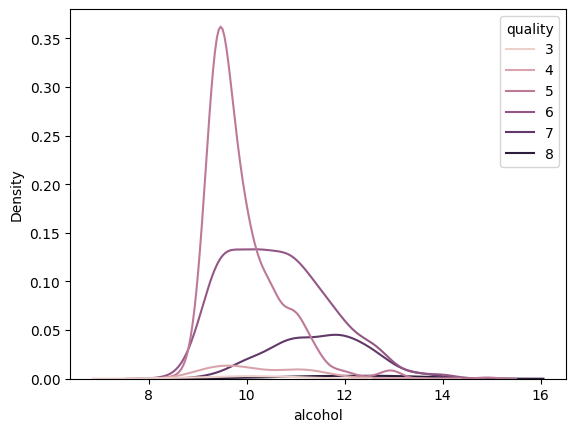

In [31]:
# Q3 - Wine dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import pandas as pd
import seaborn as sns
data = pd.read_csv("3_winequality-red.csv")

# print(data.head)

x = data.drop('quality',axis = 1)
y = data['quality']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

model = GaussianNB()
model.fit(x_train,y_train)


sample = x_test.iloc[[0]]
pred = model.predict(sample)

print("Predictions : ",pred[0])
print("Actual Quality : ",y_test.iloc[0])
print("Accuracy : ",model.score(x_test,y_test))

sns.kdeplot(data=data,x = "alcohol",hue = "quality")
plt.show()

Actual :  6
Predicted :  6


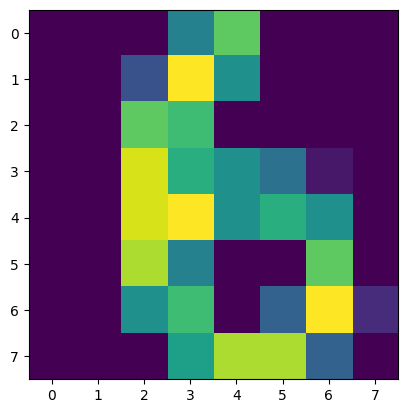

In [35]:
# q4
import pandas as pd
import numpy as np
from sklearn.model_selection  import train_test_split
from sklearn.datasets import load_digits
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt

data = load_digits()
x = data.data
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

model = GaussianNB()
model.fit(x_train,y_train)

pred = model.predict(x_test)
print("Actual : ",y_test[0])
print("Predicted : ",pred[0])

img = x_test[0].reshape(8,8)
plt.imshow(img)
plt.show()



Total Records: 3000
Anomalies: 202
Normal: 2798


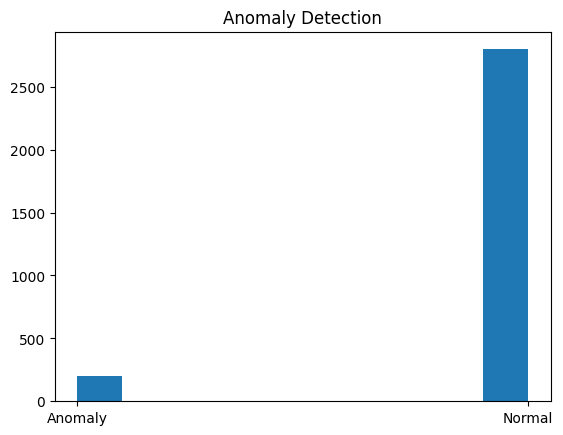

In [3]:
# Q5
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# Load data
data = fetch_kddcup99(percent10=True)
df = pd.DataFrame(data.data).head(3000)

# Preprocess (encode categorical)
for col in df.columns:
    if df[col].dtype == object:
        df[col] = LabelEncoder().fit_transform(df[col])

# Train model
model = IsolationForest()
model.fit(df)

# Predict
pred = model.predict(df)

# Output
print("Total Records:", len(pred))
print("Anomalies:", sum(pred == -1))
print("Normal:", sum(pred == 1))

# Visual
plt.hist(pred)
plt.xticks([-1,1], ["Anomaly","Normal"])
plt.title("Anomaly Detection")
plt.show()

Clinical Outcome Prediction Accuracy: 0.945010183299389


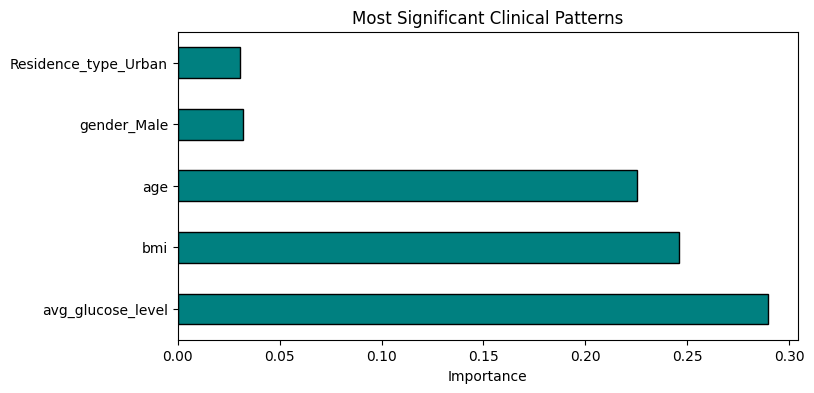

In [36]:
# Q.6)

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


df = pd.read_csv("6_healthcare-dataset-stroke-data.csv")
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df.dropna()

X = pd.get_dummies(df.drop(['id', 'stroke'], axis=1), drop_first=True)
y = df['stroke']
xt, xtst, yt, ytst = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(xt, yt)
pred = model.predict(xtst)

print("Clinical Outcome Prediction Accuracy:", accuracy_score(ytst, pred))
imp = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,4))
imp.nlargest(5).plot(kind='barh', color='teal', edgecolor='black')
plt.title("Most Significant Clinical Patterns")
plt.xlabel("Importance")
plt.show()

Actual :  1
Predicted :  1
Accuracy :  0.99


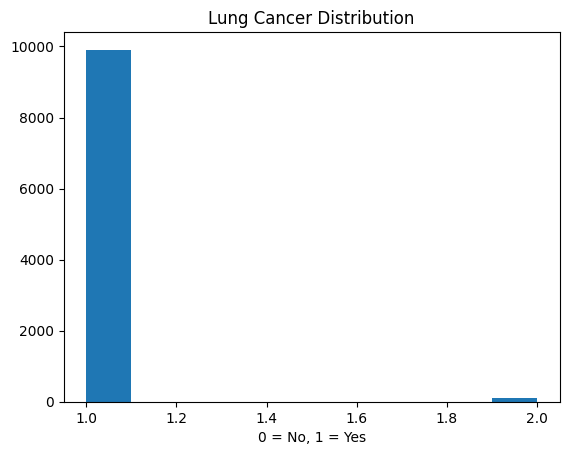

In [54]:
# q7
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv("asia_data.csv")
# print(df.columns)
x = data.drop('V4',axis = 1)
y = data['V4']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

model = BernoulliNB()
model.fit(x_train,y_train)

sample = x_test.iloc[[0]]
pred = model.predict(sample)
proba = model.predict_proba(sample)

print("Actual : ",y_test.iloc[0])
print("Predicted : ",pred[0])

print("Accuracy : ",model.score(x_test,y_test))

plt.hist(y)
plt.title("Lung Cancer Distribution")
plt.xlabel("0 = No, 1 = Yes")
plt.show()

Total Samples: 3000
Clusters (first 10): [4 6 7 8 7 0 1 2 8 5]


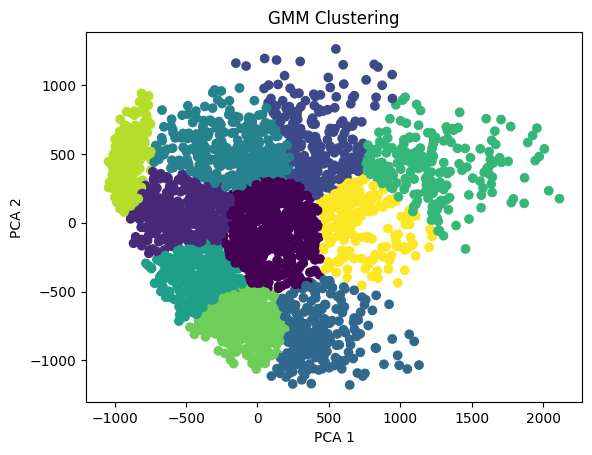

In [55]:
# q8
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

# Load data
train = pd.read_csv("8_mnist_train.csv").head(2000)
test = pd.read_csv("8_mnist_test.csv").head(1000)

df = pd.concat([train, test])

# Features
X = df.drop("label", axis=1)

# Reduce dimensions (for visualization)
X2 = PCA(n_components=2).fit_transform(X)

# Train model
model = GaussianMixture(n_components=10)
model.fit(X2)

# Predict clusters
clusters = model.predict(X2)

# Output
print("Total Samples:", len(clusters))
print("Clusters (first 10):", clusters[:10])

# Visual
plt.scatter(X2[:,0], X2[:,1], c=clusters)
plt.title("GMM Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
# Q.9) 

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train = [[1,1,1,1], [2,2,2,2], [3,3,3,3]]
y_train = ["Circle", "Square", "Triangle"]

X_test  = [[1,1,1,0], [2,2,2,1], [3,3,3,2]]
y_test  = ["Circle", "Square", "Triangle"]

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)
pred1 = knn.predict(X_test)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred2 = dt.predict(X_test)
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)

print("KNN Accuracy:", acc1)
print("Decision Tree Accuracy:", acc2)

plt.bar(["KNN", "Decision Tree"], [acc1, acc2], color=["blue", "green"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1.2)
plt.show()

print("KNN Prediction:", knn.predict([[2,2,2,1]])[0])
print("DT Prediction:", dt.predict([[2,2,2,1]])[0])

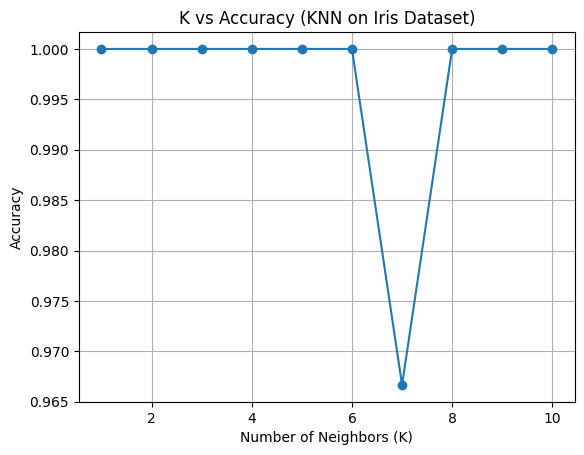

In [57]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

data = load_iris()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

acc = []

for i in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train, y_train)
    acc.append(model.score(x_test, y_test))

# Plot
plt.plot(range(1, 11), acc, marker='o')
plt.title("K vs Accuracy (KNN on Iris Dataset)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()

plt.show()